# LSTM - PRE-TRAINING IKLIM (ERA5) Interval 1 Jam


## Tahap 1: Inisialisasi dan Impor Library

Sel ini memuat semua pustaka (library) yang dibutuhkan oleh model, termasuk manipulasi data (Pandas/Numpy), pemodelan (XGBoost/Tensorflow), metrik evaluasi (Scikit-Learn), serta mematikan peringatan (*warnings*) agar *output* tetap bersih.

In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import shap
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix,
    brier_score_loss, mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...")


from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger


2026-07-01 13:58:14,731 - INFO - Kerangka Pemodelan Prediksi Curah Hujan 1-Jam Dimulai...
2026-07-01 13:58:16.704104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782914296.924078      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782914296.990788      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782914297.560613      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782914297.560661      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than onc

## Tahap 1.5: Impor Ekstra untuk Deep Learning

Sel ini memuat pustaka tambahan khusus untuk jaringan saraf tiruan (Keras/TensorFlow) dan modul *Permutation Importance*.

In [2]:
# Tambahan Impor Keras & Permutation Importance
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler



## Tahap 2: Konfigurasi Global & Konstanta

Sel ini mendefinisikan seluruh variabel kontrol untuk *pipeline*. Anda bisa mengganti mode berjalannya notebook (`RUN_MODE`) menjadi mode cepat (*fast-test*) atau mode penuh (*pipeline_test*), serta menentukan jumlah *trials* Optuna.

In [3]:
# Sel 2: Konfigurasi Global
# Mode eksekusi: 
# - "FULL_TRAIN": Untuk optimasi dan pelatihan menyeluruh
# - "PIPELINE_TEST": Untuk uji coba cepat di Lokal (data dipotong & uji coba dibatasi)
RUN_MODE = "FULL_TRAIN"  # Ubah ke "PIPELINE_TEST" untuk uji coba cepat
SEED = 281225

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS = 5
    EPOCHS = 2
else:
    OPTUNA_TRIALS = 100
    EPOCHS = 100

BASE_OUTPUT_DIR = Path('outputs_lstm')

import random
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)



## Tahap 3: Mesin Evaluasi Terpadu (*ModelEvaluator*)

Ini adalah mesin (*engine*) utama untuk melakukan pelaporan hasil model. Kelas ini bertanggung jawab menghitung semua metrik meteorologi (CSI, POD, FAR), metrik klasifikasi (ROC-AUC), metrik regresi (RMSE), serta menyimpan seluruh grafik evaluasi dan kurva kalibrasi secara otomatis ke folder `outputs_lstm/`.

In [4]:
# Sel 3: Mesin Evaluasi Terpadu (Unified Evaluation Engine)
class ModelEvaluator:
    def __init__(self):
        self.base_dir = BASE_OUTPUT_DIR
        self.dirs = {
            'models': self.base_dir / 'models',
            'models_clf': self.base_dir / 'models' / 'classifier',
            'models_reg': self.base_dir / 'models' / 'regressor',
            'models_cal': self.base_dir / 'models' / 'calibration',
            'metrics': self.base_dir / 'metrics',
            'reports': self.base_dir / 'reports',
            'plots': self.base_dir / 'plots',
        }
        
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
    def calc_meteorological_metrics(self, y_true, y_pred):
        hits = np.sum((y_pred == 1) & (y_true == 1))
        misses = np.sum((y_pred == 0) & (y_true == 1))
        false_alarms = np.sum((y_pred == 1) & (y_true == 0))
        correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
        
        total = len(y_true)
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        
        csi = hits / (hits + misses + false_alarms + 1e-9)
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
        
        return {'CSI': float(csi), 'POD': float(pod), 'FAR': float(far), 'ETS': float(ets), 'HSS': float(hss)}

    def calc_hydrological_metrics(self, y_true, y_pred):
        if len(y_true) < 2: return {'NSE': 0.0, 'KGE': 0.0, 'Correlation': 0.0}
        mean_obs, mean_sim = np.mean(y_true), np.mean(y_pred)
        std_obs, std_sim = np.std(y_true), np.std(y_pred)
        
        numerator = np.sum((y_true - y_pred)**2)
        denominator = np.sum((y_true - mean_obs)**2)
        nse = 1 - (numerator / (denominator + 1e-9))
        
        if std_obs > 0 and std_sim > 0:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            beta = mean_sim / (mean_obs + 1e-9)
            gamma = (std_sim / mean_sim) / (std_obs / mean_obs + 1e-9) if mean_sim > 0 else 0
            kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)
        else:
            r, kge = 0.0, 0.0
            
        return {'NSE': float(nse), 'KGE': float(kge), 'Correlation': float(r)}

    def evaluate_classification(self, y_true, y_prob_uncal, y_prob_cal, y_pred):
        logger.info("Menghitung metrik klasifikasi...")
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob_cal)
        
        brier_uncal = brier_score_loss(y_true, y_prob_uncal)
        brier_cal = brier_score_loss(y_true, y_prob_cal)
        
        precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob_cal)
        pr_auc = auc(recall_arr, precision_arr)
        
        metrics = {
            'Accuracy': float(acc), 
            'Precision': float(prec), 
            'Recall': float(rec), 
            'F1 Score': float(f1), 
            'ROC-AUC': float(roc_auc), 
            'PR-AUC': float(pr_auc), 
            'Brier Score (Uncalibrated)': float(brier_uncal), 'Brier Score (Calibrated)': float(brier_cal)
        }
        
        with open(self.dirs['metrics'] / 'classification_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
            
        meteo_metrics = self.calc_meteorological_metrics(y_true, y_pred)
        with open(self.dirs['metrics'] / 'meteorological_metrics.json', 'w') as f:
            json.dump(meteo_metrics, f, indent=4)
            
        
        self.plot_calibration_curve(y_true, y_prob_uncal, y_prob_cal)
        self.plot_reliability_diagram(y_true, y_prob_uncal, y_prob_cal)
        self.plot_probability_distribution(y_prob_cal)
        self.plot_roc_curve(y_true, y_prob_cal)
        self.plot_precision_recall_curve(y_true, y_prob_cal)
        self.plot_threshold_analysis(y_true, y_prob_cal)
        
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics, meteo_metrics

    def evaluate_regression(self, y_true, y_pred):
        logger.info("Menghitung metrik regresi...")
        if len(y_true) == 0: return {}
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        hydro = self.calc_hydrological_metrics(y_true, y_pred)
        
        metrics = {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'Bias': float(bias)}
        metrics.update(hydro)
        
        with open(self.dirs['metrics'] / 'regression_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=4)
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        return metrics

    # --- 01_probability plots ---
    def plot_reliability_diagram(self, y_true, y_prob_uncal, y_prob_cal):
        plt.figure(figsize=(8,6))
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Reliability Diagram')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'reliability_diagram.png')
        plt.show()

    def plot_probability_distribution(self, y_prob_cal):
        plt.figure(figsize=(8,6))
        sns.histplot(y_prob_cal, bins=20, kde=True, color='green', alpha=0.5)
        plt.title('Probability Distribution')
        plt.xlabel('Probabilitas Klasifikasi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'probability_distribution.png')
        plt.show()

    def plot_calibration_curve(self, y_true, y_prob_uncal, y_prob_cal=None):
        plt.figure(figsize=(8,6))
        prob_true, prob_pred = calibration_curve(y_true, y_prob_uncal, n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated Model', color='blue')
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated Model', color='green')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Calibration Curve (Uncalibrated vs Calibrated)')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Kejadian Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'calibration_curve.png')
        plt.show()

    # --- 02_classification plots ---
    def plot_confusion_matrix(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix')
        plt.xlabel('Prediksi')
        plt.ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'confusion_matrix.png')
        plt.show()
        
    def plot_roc_curve(self, y_true, y_prob):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, color='darkorange', lw=2)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'roc_curve.png')
        plt.show()

    def plot_precision_recall_curve(self, y_true, y_prob):
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(recall, precision, color='purple', lw=2)
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'precision_recall_curve.png')
        plt.show()

    def plot_threshold_analysis(self, y_true, y_prob):
        thresholds = np.linspace(0.1, 0.9, 50)
        f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        plt.figure(figsize=(8,5))
        plt.plot(thresholds, f1_scores, marker='x', color='blue')
        plt.title('Threshold Analysis (F1 Score)')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'threshold_analysis.png')
        plt.show()

    # --- 03_regression plots ---
    def plot_prediction_vs_observation(self, y_true, y_pred):
        if len(y_true) == 0: return
        plt.figure(figsize=(8,8))
        plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
        max_val = max(np.max(y_true), np.max(y_pred))
        plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        plt.title('Prediction vs Observation')
        plt.xlabel('Observasi (mm)')
        plt.ylabel('Prediksi (mm)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'prediction_vs_observation.png')
        plt.show()

    def plot_residual_distribution(self, residuals):
        plt.figure(figsize=(8,6))
        sns.histplot(residuals, kde=True, color='crimson')
        plt.title('Residual Distribution')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'residual_distribution.png')
        plt.show()
        
    def plot_qq_plot(self, residuals):
        plt.figure(figsize=(6,6))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title('QQ Plot of Residuals')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'qq_plot.png')
        plt.show()

    def plot_error_distribution(self, y_true, y_pred):
        abs_errors = np.abs(y_true - y_pred)
        plt.figure(figsize=(8,6))
        sns.boxplot(y=abs_errors, color='orange')
        plt.title('Error Distribution (Absolute)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'error_distribution.png')
        plt.show()

    # --- 04_timeseries plots ---
    def plot_timeseries_prediction_vs_observation(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(15, 5))
        plt.plot(timestamps, y_true, label='Observasi', color='blue', alpha=0.7)
        plt.plot(timestamps, y_pred, label='Prediksi', color='red', alpha=0.7)
        plt.title('Timeseries: Prediction vs Observation')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'timeseries_prediction_vs_observation.png')
        plt.show()

    def plot_rainfall_event_comparison(self, y_true, y_pred):
        plt.figure(figsize=(10, 5))
        idx = np.argsort(y_true)[::-1][:50] # Top 50 extreme events
        plt.bar(np.arange(len(idx)) - 0.2, np.array(y_true)[idx], width=0.4, label='Observasi')
        plt.bar(np.arange(len(idx)) + 0.2, np.array(y_pred)[idx], width=0.4, label='Prediksi')
        plt.title('Rainfall Event Comparison (Top 50)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'rainfall_event_comparison.png')
        plt.show()

    def plot_cumulative_rainfall(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(10, 6))
        plt.plot(timestamps, np.cumsum(y_true), label='Cumulative Observasi', color='blue')
        plt.plot(timestamps, np.cumsum(y_pred), label='Cumulative Prediksi', color='red')
        plt.title('Cumulative Rainfall')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'cumulative_rainfall.png')
        plt.show()

    # --- Laporan ---
    def generate_report(self, n_train, n_val, n_test, feature_names, clf_metrics, meteo_metrics, reg_metrics, algorithm_name):
        features_list = "\n".join([f"- {f}" for f in feature_names])
        
        report_content = f"""# Laporan Evaluasi Model Prediksi Curah Hujan 1 Jam
        
## Deskripsi Model
Framework ini membangun arsitektur dua tahap (*Two-Stage Model*) untuk memprediksi curah hujan akumulasi 1-jam.
Tahap pertama mengklasifikasikan kejadian hujan (P(Hujan) $\ge$ 1.0 mm), kemudian tahap kedua (regresi) menebak nilai intensitas untuk wilayah yang diklasifikasikan hujan.
**Algoritma Inti:** {algorithm_name}

## Jumlah Data
- **Jumlah Data Latih**: {n_train}
- **Jumlah Data Validasi**: {n_val}
- **Jumlah Data Uji**: {n_test}

## Daftar Variabel
{features_list}

## Hasil Klasifikasi
- Accuracy: {clf_metrics.get('Accuracy', 0):.4f}
- Precision: {clf_metrics.get('Precision', 0):.4f}
- Recall: {clf_metrics.get('Recall', 0):.4f}
- F1 Score: {clf_metrics.get('F1 Score', 0):.4f}
- ROC-AUC: {clf_metrics.get('ROC-AUC', 0):.4f}
- PR-AUC: {clf_metrics.get('PR-AUC', 0):.4f}
- Brier Score (Uncalibrated): {clf_metrics.get('Brier Score (Uncalibrated)', 0):.4f}
- Brier Score (Calibrated): {clf_metrics.get('Brier Score (Calibrated)', 0):.4f}

## Hasil Metrik Meteorologi
- CSI (Critical Success Index): {meteo_metrics.get('CSI', 0):.4f}
- POD (Probability of Detection): {meteo_metrics.get('POD', 0):.4f}
- FAR (False Alarm Ratio): {meteo_metrics.get('FAR', 0):.4f}
- ETS (Equitable Threat Score): {meteo_metrics.get('ETS', 0):.4f}
- HSS (Heidke Skill Score): {meteo_metrics.get('HSS', 0):.4f}

## Hasil Regresi
*(Dihitung eksklusif pada sampel aktual yang mengalami hujan)*
- RMSE (Root Mean Squared Error): {reg_metrics.get('RMSE', 0):.4f} mm
- MAE (Mean Absolute Error): {reg_metrics.get('MAE', 0):.4f} mm
- R² (Koefisien Determinasi): {reg_metrics.get('R2', 0):.4f}
- NSE (Nash-Sutcliffe Efficiency): {reg_metrics.get('NSE', 0):.4f}
- KGE (Kling-Gupta Efficiency): {reg_metrics.get('KGE', 0):.4f}
- Bias: {reg_metrics.get('Bias', 0):.4f}
- Correlation: {reg_metrics.get('Correlation', 0):.4f}

## Analisis Feature Importance
*Silakan merujuk ke folder `plots/` untuk melihat visualisasi SHAP dan diagram kepentingan fitur (Feature Importance) terhadap prediksi model.*

## Kesimpulan Performa Model
Berdasarkan nilai Brier Score, model mengalami perbaikan/penyesuaian keandalan probabilitas setelah kalibrasi Isotonic. 
Performa metrik meteorologi utama (CSI dan POD) menunjukkan akurasi model {algorithm_name} dalam menangkap fenomena presipitasi 1-jam ke depan.
"""
        with open(self.dirs['reports'] / 'summary_report_lstm.md', 'w') as f:
            f.write(report_content)



## FASE 1: PRE-TRAINING (Data Satelit & ERA5)

**Tujuan:** Melatih model dasar menggunakan data historis berskala besar.
Sel ini bertugas menyatukan *dataset* ERA5 Standard dan ERA5 ML Features. Semua fitur utama (`temperature`, `humidity`, dll) **diambil sepenuhnya dari data proksi ERA5**.

In [5]:
# --- FASE PRE-TRAINING ---
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge) untuk PRE-TRAINING
import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Mendeteksi Environment & Memuat data ERA5 untuk Pre-Training...")

if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv', recursive=True)
    if search_file:
        SAT_DIR = Path(search_file[0]).parent
    else:
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat ERA5 Standard Units (ERA5-Land)
df_era5_std = pd.read_csv(SAT_DIR / 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv')
df_era5_std['timestamp'] = pd.to_datetime(df_era5_std['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_std = df_era5_std.set_index('timestamp').sort_index()

# 2. Memuat ERA5 ML Features (ERA5)
df_era5_ml = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5_ml.columns:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
else:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['unixtime'], unit='s', utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_ml = df_era5_ml.set_index('timestamp').sort_index()

# Gabungkan kedua dataset ERA5
df_era5 = df_era5_std.join(df_era5_ml, how='inner', lsuffix='_std', rsuffix='_ml')

df_merged = df_era5.copy()

# Pemetaan Variabel Dasar
df_merged['temperature'] = df_merged['temperature_2m_C']
df_merged['humidity'] = df_merged['humidity_2m_pct']
df_merged['dewpoint'] = df_merged['dewpoint_temperature_2m_C']
df_merged['rainrate'] = df_merged['total_precipitation_hourly_mm']
df_merged['pressure'] = df_merged['surface_pressure_hPa']

# Fitur Angin ERA5
df_merged['era5_u_wind'] = df_merged['u_component_of_wind_10m_ms']
df_merged['era5_v_wind'] = df_merged['v_component_of_wind_10m_ms']

# Fitur ERA5 ML (Ekstraksi Fitur Konvektif Tambahan)
df_merged['era5_cape'] = df_merged['cape_era5']
df_merged['era5_tcwv'] = df_merged['total_column_water_vapour_era5']
df_merged['era5_k_index'] = df_merged['k_index_era5']
df_merged['era5_moisture_div'] = df_merged['moisture_divergence_era5']
df_merged['era5_total_totals'] = df_merged['total_totals_index_era5']
df_merged['era5_wind_gusts'] = df_merged['wind_gusts_era5']
df_merged['era5_direct_radiation'] = df_merged['direct_radiation_era5']
df_merged['era5_cloud_cover'] = df_merged['cloud_cover_era5']
df_merged['era5_soil_moisture'] = df_merged['soil_moisture_era5']
df_merged['era5_sunshine'] = df_merged['sunshine_duration_era5']

df_hourly = df_merged.dropna(subset=['temperature']).copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data dasar terpadu (PRE-TRAINING): {df_hourly.shape}")


2026-07-01 13:58:29,788 - INFO - Mendeteksi Environment & Memuat data ERA5 untuk Pre-Training...
2026-07-01 13:58:32,764 - INFO - Dimensi data dasar terpadu (PRE-TRAINING): (231528, 49)


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [6]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'humidity', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'humidity' in df_base.columns:
        T = df_base['temperature']
        RH = df_base['humidity']
        e_s = 0.611 * np.exp((17.27 * T) / (T + 237.3))
        e_a = e_s * (RH / 100.0)
        df_base['vpd_kpa'] = e_s - e_a
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    df = df_base.copy()
    
    if 'era5_u_wind' in df.columns and 'era5_v_wind' in df.columns and 'era5_wind_speed' not in df.columns:
        df['era5_wind_speed'] = np.sqrt(df['era5_u_wind']**2 + df['era5_v_wind']**2)

    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 4.5: Persiapan Parameter LSTM

Sel ini mengatur ukuran jendela sekuens (*lookback window*) yang akan dibaca oleh memori LSTM.

In [7]:
# Sel 6: Setup Parameter Dasar & Split Data LSTM
import optuna
import gc
from tensorflow.keras import backend as K

# ==========================================
# LSTM HYPERPARAMETER CONFIGURATION
# ==========================================
LOOKBACK = 24
# ==========================================

logger.info(f"\n{'='*50}\nMEMULAI TRAINING LSTM 3-JAM (OPTUNA HPO)\n{'='*50}")
evaluator = ModelEvaluator()

df_features = engineer_features(df_hourly)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= 0.5).astype(int)

# 3. Data Split
if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.6)
    val_mask = (np.arange(n) >= int(n * 0.6)) & (np.arange(n) < int(n * 0.8))
    test_mask = np.arange(n) >= int(n * 0.8)
else:
# [PEMBAGIAN DATA PRE-TRAINING BERDASARKAN TANGGAL]
# Train : 31 Jan 2004 - Akhir 2023 (Menyesuaikan ketersediaan data Satelit Oya)
    train_mask = (df_features.index >= '2004-01-31') & (df_features.index <= '2023-12-31')
# Val   : Sepanjang Tahun 2024
    val_mask = (df_features.index >= '2024-01-01') & (df_features.index <= '2024-12-31')
# Test  : Sepanjang Tahun 2025
    test_mask = (df_features.index >= '2025-01-01') & (df_features.index <= '2025-12-31')

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

def make_3d(X_df, y_o, y_r, lookback):
    X_arr, yo_arr, yr_arr = [], [], []
    for i in range(len(X_df) - lookback + 1):
        X_arr.append(X_df.iloc[i:i+lookback].values)
        yo_arr.append(y_o.iloc[i+lookback-1])
        yr_arr.append(y_r.iloc[i+lookback-1])
    return np.array(X_arr, dtype=np.float32), np.array(yo_arr, dtype=np.float32), np.array(yr_arr, dtype=np.float32)

# Sequence Generation
X_tr_seq, y_tr_o, y_tr_r = make_3d(X_scaled[train_mask], y_occ[train_mask], y_reg[train_mask], LOOKBACK)
X_va_seq, y_va_o, y_va_r = make_3d(X_scaled[val_mask], y_occ[val_mask], y_reg[val_mask], LOOKBACK)
X_te_seq, y_te_o, y_te_r = make_3d(X_scaled[test_mask], y_occ[test_mask], y_reg[test_mask], LOOKBACK)


2026-07-01 13:58:32,822 - INFO - 
MEMULAI TRAINING LSTM 3-JAM (OPTUNA HPO)
2026-07-01 13:58:32,823 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-01 13:58:33,116 - INFO - Dimensi akhir setelah rekayasa fitur: (231506, 61)


## Tahap 5: Pelatihan Klasifikasi Hujan (Optuna LSTM)

Di sini model Jaringan Saraf Tiruan (LSTM) dilatih untuk mengenali apakah curah hujan akan mencapai ambang batas (>= 1.0 mm) atau tidak berdasarkan sekuens waktu.

2026-07-01 13:58:39,360 - INFO - Memulai HPO Optuna untuk LSTM Classifier...
[I 2026-07-01 13:58:39,361] A new study created in memory with name: no-name-8ab254ff-b6b8-48e4-a6cb-80d806cae1f9
I0000 00:00:1782914320.932016      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1782914326.528195      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
[I 2026-07-01 13:59:25,478] Trial 0 finished with value: 0.20468589663505554 and parameters: {'units': 32, 'lr': 0.0023934856559276276, 'dropout': 0.23729511453362137, 'batch_size': 128}. Best is trial 0 with value: 0.20468589663505554.
[I 2026-07-01 14:00:57,273] Trial 1 finished with value: 0.19432583451271057 and parameters: {'units': 128, 'lr': 0.0006352402711106024, 'dropout': 0.18002267001104183, 'batch_size': 64}. Best is trial 1 with value: 0.19432583451271057.
[I 2026-07-01 14:02:

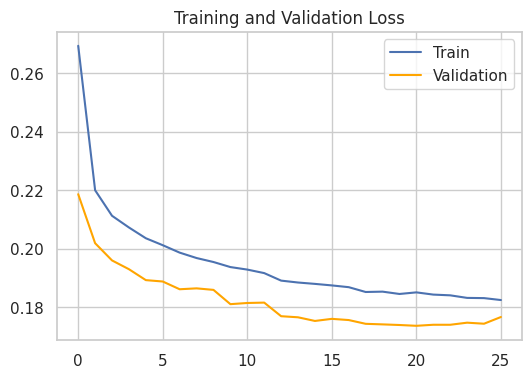

['outputs_lstm/models/calibration/isotonic_calibrator.pkl']

In [8]:
# Sel 7: Optuna Tuning untuk Classifier LSTM
def build_lstm_clf(lookback, units, lr, dropout):
    model = Sequential([
        Input(shape=(lookback, X.shape[1])),
        LSTM(units, return_sequences=False),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def objective_clf(trial):
    K.clear_session()
    gc.collect()
    
    units = trial.suggest_categorical('units', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    model = build_lstm_clf(LOOKBACK, units, lr, dropout)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    model.fit(X_tr_seq, y_tr_o, validation_data=(X_va_seq, y_va_o), 
              epochs=EPOCHS, batch_size=batch_size, callbacks=[es], verbose=0)
              
    val_loss, _ = model.evaluate(X_va_seq, y_va_o, verbose=0)
    return val_loss

logger.info("Memulai HPO Optuna untuk LSTM Classifier...")
optuna.logging.set_verbosity(optuna.logging.INFO)
study_clf = optuna.create_study(direction='minimize')
study_clf.optimize(objective_clf, n_trials=OPTUNA_TRIALS)

best_clf_params = study_clf.best_params
logger.info(f"Parameter terbaik Classifier: {best_clf_params}")

# Melatih ulang dengan parameter terbaik
K.clear_session()
gc.collect()

clf_best = build_lstm_clf(LOOKBACK, best_clf_params['units'], best_clf_params['lr'], best_clf_params['dropout'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

history_clf = clf_best.fit(X_tr_seq, y_tr_o, validation_data=(X_va_seq, y_va_o), 
                           epochs=EPOCHS, 
                           batch_size=best_clf_params['batch_size'], 
                           callbacks=[es, reduce_lr], 
                           verbose=0)

# Simpan Kurva
plt.figure(figsize=(6,4))
plt.plot(history_clf.history['loss'], label='Train')
plt.plot(history_clf.history['val_loss'], label='Validation', color='orange')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig(evaluator.dirs['plots'] / 'training_loss_clf.png')
plt.show()

clf_best.save(evaluator.dirs['models_clf'] / 'best_lstm_occ.keras')

# Probability Calibration
iso_reg = IsotonicRegression(out_of_bounds='clip')
val_probs_uncal = clf_best.predict(X_va_seq, verbose=0).flatten()
iso_reg.fit(val_probs_uncal, y_va_o)
joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator.pkl')


## Tahap 6: Pelatihan Regresi Intensitas (Optuna LSTM)

Setelah model tahu bahwa akan turun hujan, model *Regressor* ini bertugas menebak **Berapa lebat hujannya?** (dalam satuan milimeter).

2026-07-01 17:52:04,905 - INFO - Memulai HPO Optuna untuk LSTM Regressor...
[I 2026-07-01 17:52:04,906] A new study created in memory with name: no-name-b73be246-28c1-48c1-b759-1867513a774d
[I 2026-07-01 17:52:45,646] Trial 0 finished with value: 0.11390583962202072 and parameters: {'units': 64, 'lr': 0.0001850054930532866, 'dropout': 0.23356489899421784, 'batch_size': 64}. Best is trial 0 with value: 0.11390583962202072.
[I 2026-07-01 17:53:29,649] Trial 1 finished with value: 0.11166426539421082 and parameters: {'units': 64, 'lr': 0.0002339239472429778, 'dropout': 0.370075909466255, 'batch_size': 64}. Best is trial 1 with value: 0.11166426539421082.
[I 2026-07-01 17:53:54,892] Trial 2 finished with value: 0.10947810113430023 and parameters: {'units': 64, 'lr': 0.0012783870034825233, 'dropout': 0.36463322716560087, 'batch_size': 128}. Best is trial 2 with value: 0.10947810113430023.
[I 2026-07-01 17:54:19,490] Trial 3 finished with value: 0.11015371978282928 and parameters: {'units': 

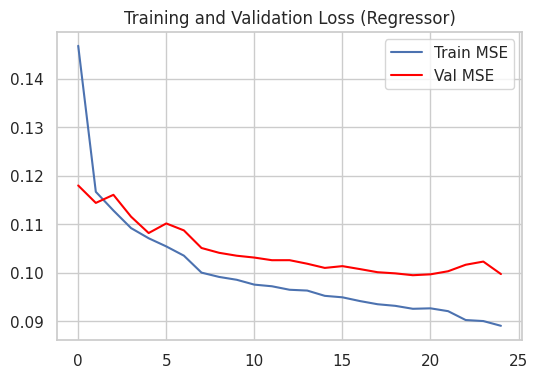

In [9]:
# Sel 8: Optuna Tuning untuk Regressor LSTM
# Hanya melatih data yang aktualnya hujan
rainy_tr = y_tr_o == 1
rainy_va = y_va_o == 1

if np.sum(rainy_tr) > 10:
    X_tr_r_val, y_tr_r_val = X_tr_seq[rainy_tr], np.log1p(y_tr_r[rainy_tr])
    X_va_r_val, y_va_r_val = X_va_seq[rainy_va], np.log1p(y_va_r[rainy_va])
    
    def build_lstm_reg(lookback, units, lr, dropout):
        model = Sequential([
            Input(shape=(lookback, X.shape[1])),
            LSTM(units, return_sequences=False),
            Dropout(dropout),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        return model
        
    def objective_reg(trial):
        K.clear_session()
        gc.collect()
        
        units = trial.suggest_categorical('units', [32, 64])
        lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        dropout = trial.suggest_float('dropout', 0.1, 0.4)
        batch_size = trial.suggest_categorical('batch_size', [64, 128])
        
        model = build_lstm_reg(LOOKBACK, units, lr, dropout)
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        
        model.fit(X_tr_r_val, y_tr_r_val, validation_data=(X_va_r_val, y_va_r_val), 
                  epochs=EPOCHS, batch_size=batch_size, callbacks=[es], verbose=0)
                  
        val_loss = model.evaluate(X_va_r_val, y_va_r_val, verbose=0)
        return val_loss
        
    logger.info("Memulai HPO Optuna untuk LSTM Regressor...")
    study_reg = optuna.create_study(direction='minimize')
    study_reg.optimize(objective_reg, n_trials=OPTUNA_TRIALS)
    
    best_reg_params = study_reg.best_params
    logger.info(f"Parameter terbaik Regressor: {best_reg_params}")
    
    K.clear_session()
    gc.collect()
    
    reg_best = build_lstm_reg(LOOKBACK, best_reg_params['units'], best_reg_params['lr'], best_reg_params['dropout'])
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    
    history_reg = reg_best.fit(X_tr_r_val, y_tr_r_val, validation_data=(X_va_r_val, y_va_r_val), 
                               epochs=EPOCHS, batch_size=best_reg_params['batch_size'], 
                               callbacks=[es, reduce_lr], verbose=0)
                               
    plt.figure(figsize=(6,4))
    plt.plot(history_reg.history['loss'], label='Train MSE')
    plt.plot(history_reg.history['val_loss'], label='Val MSE', color='red')
    plt.title('Training and Validation Loss (Regressor)')
    plt.legend()
    plt.savefig(evaluator.dirs['plots'] / 'training_loss_reg.png')
    plt.show()
    
    reg_best.save(evaluator.dirs['models_reg'] / 'best_lstm_reg.keras')
else:
    logger.warning("Tidak cukup sampel hujan untuk melatih regressor.")
    reg_best = None


## FASE 2: FINE-TUNING (Data Aktual Stasiun AWS)

**Tujuan:** Menyelaraskan model dengan kondisi iklim lokal.
Sel ini menukar sumber data dasar menjadi **data pengukuran asli dari Stasiun AWS**, sembari mempertahankan fitur Angin dan Konvektif yang dipinjam secara dinamis dari ERA5.

In [10]:
# --- FASE FINE-TUNING ---
# Pemuatan Data dan Penyatuan (Data Loading & Merge)
import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Mendeteksi Environment & Memuat data stasional dan satelit...")

if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/id-05_clear_data_hourly.csv', recursive=True)
    if search_file:
        STATION_FILE = Path(search_file[0])
        sat_search = glob.glob('/kaggle/input/**/ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv', recursive=True)
        if sat_search:
            SAT_DIR = Path(sat_search[0]).parent
        else:
            SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
    else:
        STATION_FILE = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Stasiun/id-05_clear_data_hourly.csv')
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    STATION_FILE = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit' / 'id-05_clear_data_hourly.csv'
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat Data Stasiun AWS Lokal
df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_local'], utc=True).dt.tz_convert('Asia/Jakarta')
df_station = df_station.set_index('timestamp').sort_index()
# Hanya ambil kolom yang relevan dari AWS
cols_to_keep = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
df_station = df_station[cols_to_keep]

# 2. Memuat ERA5 (Identik dengan Pretraining)
df_era5_std = pd.read_csv(SAT_DIR / 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv')
df_era5_std['timestamp'] = pd.to_datetime(df_era5_std['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_std = df_era5_std.set_index('timestamp').sort_index()

df_era5_ml = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5_ml.columns:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['datetime_utc'], utc=True).dt.tz_convert('Asia/Jakarta')
else:
    df_era5_ml['timestamp'] = pd.to_datetime(df_era5_ml['unixtime'], unit='s', utc=True).dt.tz_convert('Asia/Jakarta')
df_era5_ml = df_era5_ml.set_index('timestamp').sort_index()

df_era5 = df_era5_std.join(df_era5_ml, how='inner', lsuffix='_std', rsuffix='_ml')

df_merged = df_era5.copy()

# Pemetaan Variabel ERA5 Dasar
df_merged['temperature'] = df_merged['temperature_2m_C']
df_merged['humidity'] = df_merged['humidity_2m_pct']
df_merged['dewpoint'] = df_merged['dewpoint_temperature_2m_C']
df_merged['rainrate'] = df_merged['total_precipitation_hourly_mm']
df_merged['pressure'] = df_merged['surface_pressure_hPa']

# [REPLACEMENT AWS]
# Gabungkan dengan AWS. Di mana AWS ada, timpa ERA5!
df_merged.update(df_station)

# Fitur Angin ERA5
df_merged['era5_u_wind'] = df_merged['u_component_of_wind_10m_ms']
df_merged['era5_v_wind'] = df_merged['v_component_of_wind_10m_ms']

# Fitur ERA5 ML (Ekstraksi Fitur Konvektif Tambahan)
df_merged['era5_cape'] = df_merged['cape_era5']
df_merged['era5_tcwv'] = df_merged['total_column_water_vapour_era5']
df_merged['era5_k_index'] = df_merged['k_index_era5']
df_merged['era5_moisture_div'] = df_merged['moisture_divergence_era5']
df_merged['era5_total_totals'] = df_merged['total_totals_index_era5']
df_merged['era5_wind_gusts'] = df_merged['wind_gusts_era5']
df_merged['era5_direct_radiation'] = df_merged['direct_radiation_era5']
df_merged['era5_cloud_cover'] = df_merged['cloud_cover_era5']
df_merged['era5_soil_moisture'] = df_merged['soil_moisture_era5']
df_merged['era5_sunshine'] = df_merged['sunshine_duration_era5']

# Potong dataset mulai 2025 (mencakup 2025 dan 2026)
df_merged = df_merged[df_merged.index >= '2025-01-01']

df_hourly = df_merged.dropna(subset=['temperature']).copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data terpadu (FINE-TUNING): {df_hourly.shape}")


2026-07-01 19:19:04,573 - INFO - Mendeteksi Environment & Memuat data stasional dan satelit...
2026-07-01 19:19:06,480 - INFO - Dimensi data terpadu (FINE-TUNING): (12367, 49)


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [11]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'humidity', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
            
    if 'temperature' in df_base.columns and 'humidity' in df_base.columns:
        T = df_base['temperature']
        RH = df_base['humidity']
        e_s = 0.611 * np.exp((17.27 * T) / (T + 237.3))
        e_a = e_s * (RH / 100.0)
        df_base['vpd_kpa'] = e_s - e_a
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    df = df_base.copy()
    
    if 'era5_u_wind' in df.columns and 'era5_v_wind' in df.columns and 'era5_wind_speed' not in df.columns:
        df['era5_wind_speed'] = np.sqrt(df['era5_u_wind']**2 + df['era5_v_wind']**2)

    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 4.75: Pembentukan Sekuens Data Waktu

Mengubah data tabular (2D) menjadi format sekuens (3D) `[samples, timesteps, features]` yang disyaratkan oleh arsitektur LSTM.

In [12]:
# Sel 5.5: Preparasi Sequence dan Split Data
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras
import pandas as pd

LOOKBACK = 24

# Fitur untuk prediksi (Gunakan engineer_features untuk agregasi 1 jam!)
df_features = engineer_features(df_hourly)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()

# [PEMBAGIAN DATA FINE-TUNING BERDASARKAN TANGGAL]
# Train : Sepanjang Tahun 2025
train_mask = (df_features.index >= '2025-01-01') & (df_features.index <= '2025-12-31')
# Test  : 1 Januari 2026 - 31 Maret 2026
test_mask = (df_features.index >= '2026-01-01') & (df_features.index <= '2026-03-31')
# Val   : Sama dengan test untuk menghindari data leakage
val_mask = test_mask

X_all = df_features.drop(columns=['target_amount']).values
y_all_r = df_features['target_amount'].values
y_all_o = (y_all_r > 0).astype(int)

scaler = StandardScaler()
scaler.fit(X_all[train_mask])
X_scaled = scaler.transform(X_all)

def create_sequences(X_arr, y_arr, time_steps):
    Xs, ys = [], []
    for i in range(len(X_arr) - time_steps):
        Xs.append(X_arr[i:(i + time_steps)])
        ys.append(y_arr[i + time_steps])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq, y_o_seq = create_sequences(X_scaled, y_all_o, LOOKBACK)
_, y_r_seq = create_sequences(X_scaled, y_all_r, LOOKBACK)

train_mask_seq = train_mask[LOOKBACK:]
val_mask_seq = val_mask[LOOKBACK:]
test_mask_seq = test_mask[LOOKBACK:]

X_tr_seq, y_tr_o, y_tr_r = X_seq[train_mask_seq], y_o_seq[train_mask_seq], y_r_seq[train_mask_seq]
X_v_seq, y_v_o, y_v_r = X_seq[val_mask_seq], y_o_seq[val_mask_seq], y_r_seq[val_mask_seq]
X_te_seq, y_te_o, y_te_r = X_seq[test_mask_seq], y_o_seq[test_mask_seq], y_r_seq[test_mask_seq]


2026-07-01 19:19:06,597 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-01 19:19:06,614 - INFO - Dimensi akhir setelah rekayasa fitur: (12366, 61)


## Tahap Terakhir: Proses Fine-Tuning & Perbandingan Model (LSTM)

Di tahap ini, bobot dari model LSTM global digunakan sebagai basis (Pre-trained) dan di-*retrain* secara hati-hati menggunakan dataset lokal (AWS). Laporan komparasi performa akan dicetak secara otomatis.

2026-07-01 19:19:06,804 - INFO - Mengevaluasi Model Pre-Trained pada Data Test AWS...
2026-07-01 19:19:07,337 - INFO - Memulai Fine-Tuning Classifier...
2026-07-01 19:19:53,234 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2026-07-01 19:19:53,601 - INFO - Memulai Fine-Tuning Regressor...
2026-07-01 19:20:10,926 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2026-07-01 19:20:11,144 - INFO - Menghitung metrik klasifikasi...


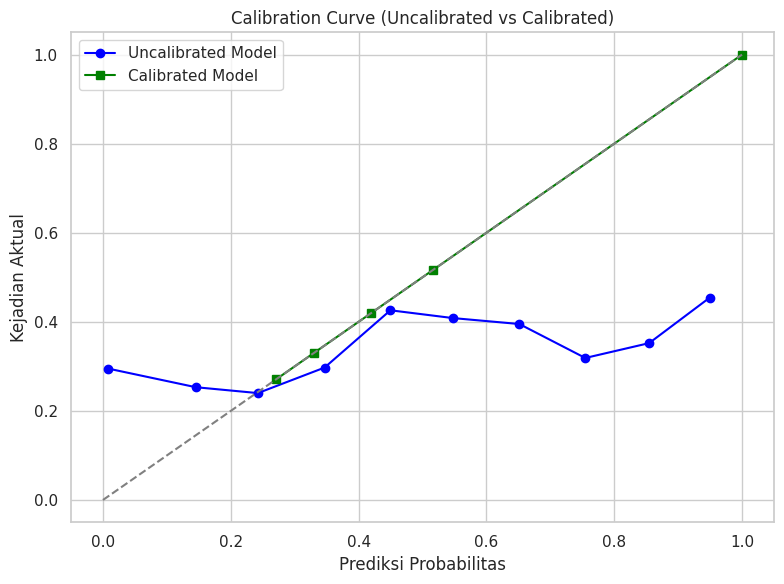

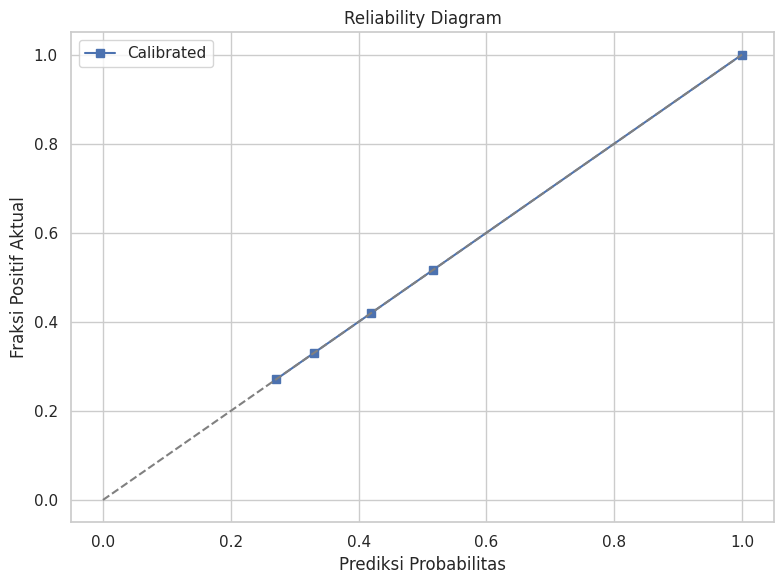

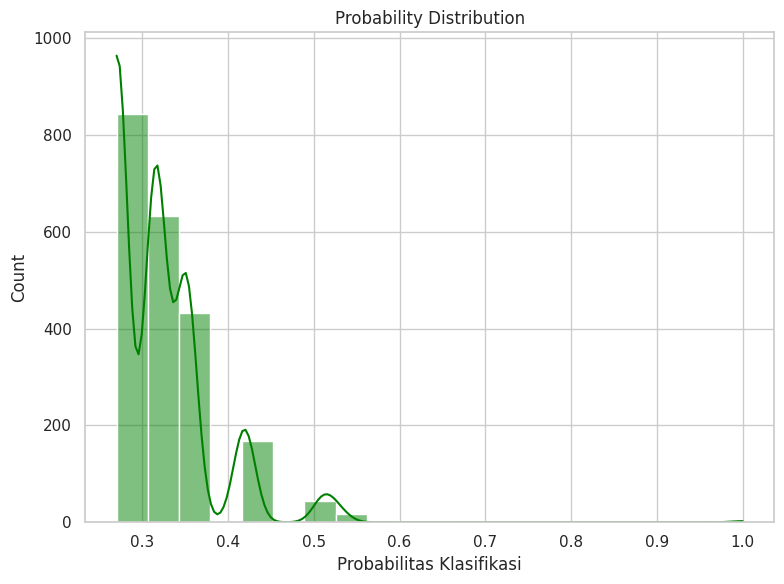

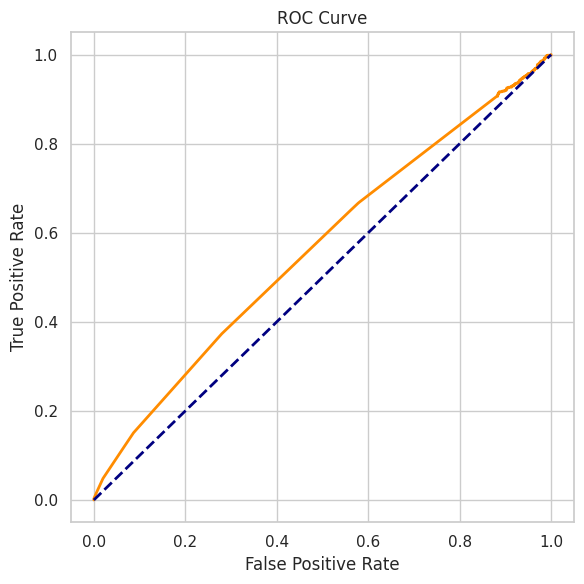

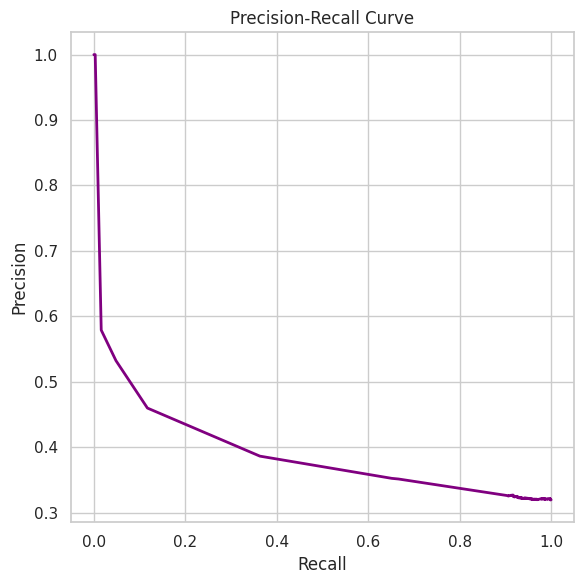

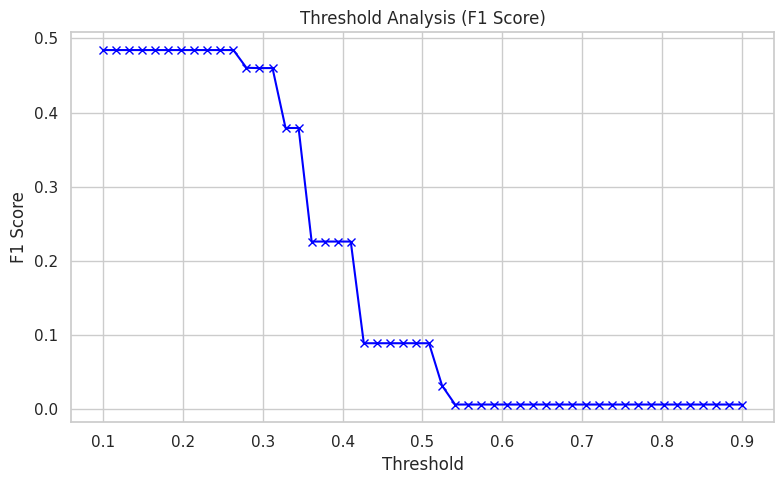

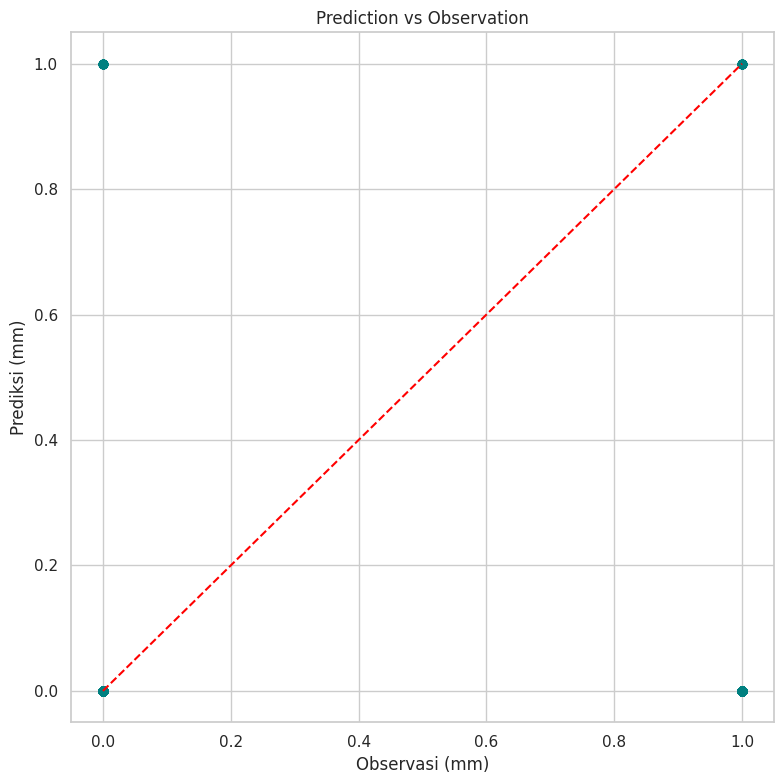

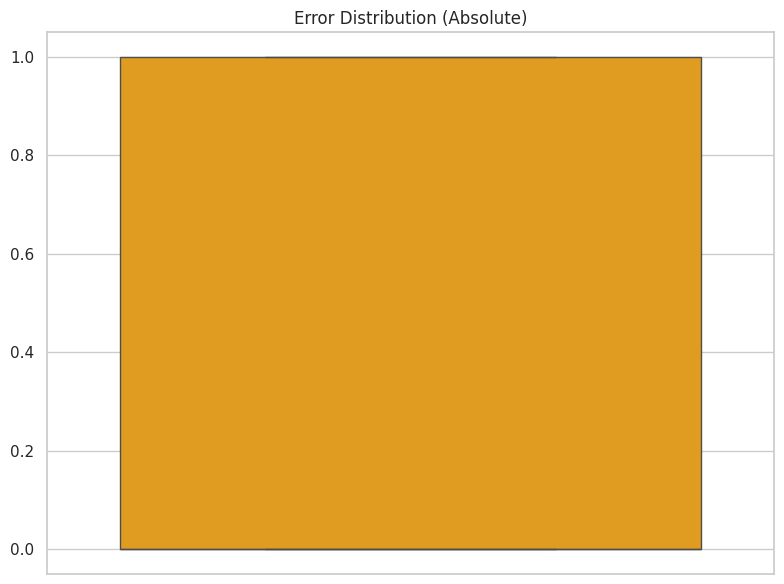

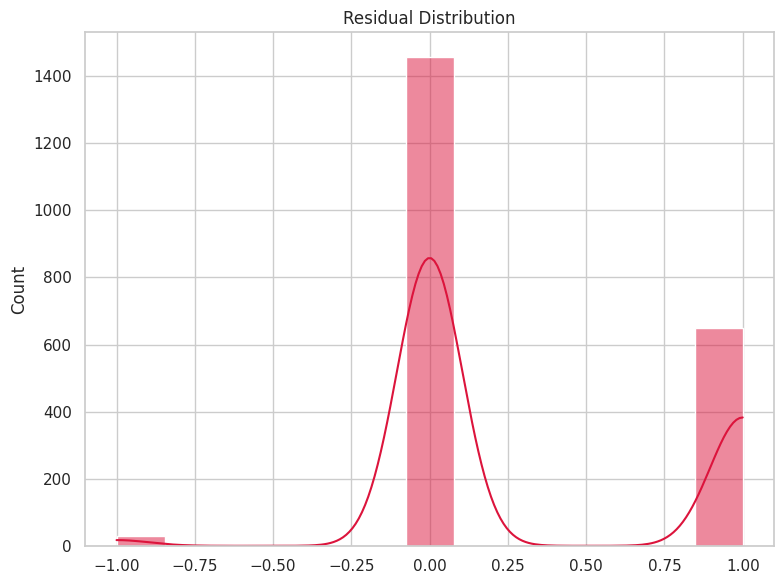

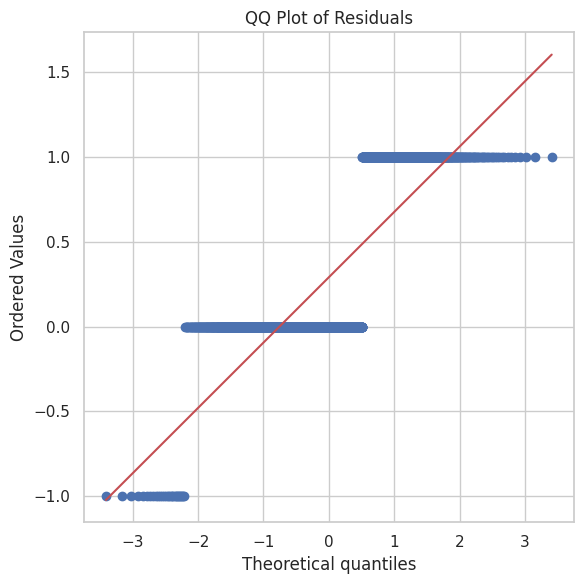

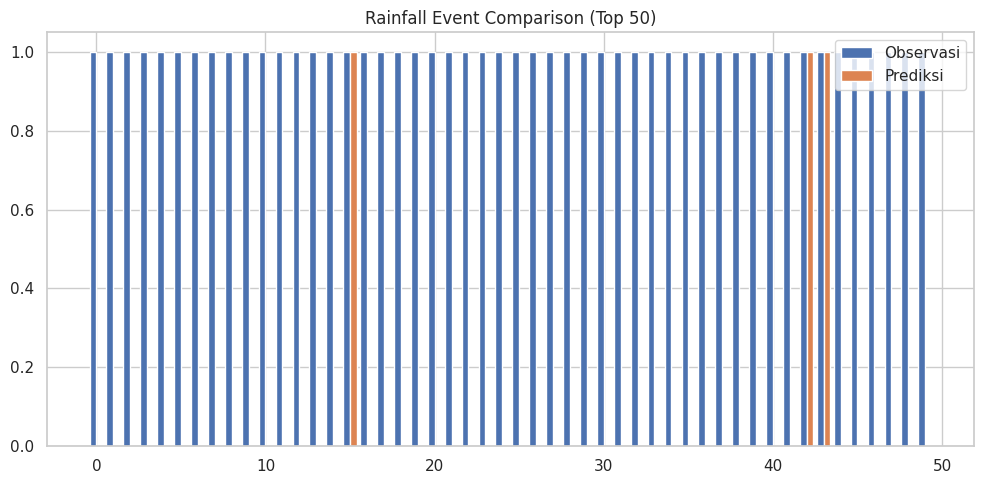

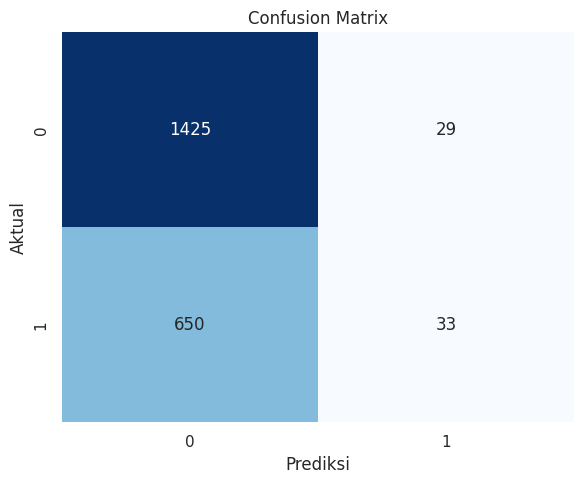

2026-07-01 19:20:14,448 - INFO - Menghitung metrik regresi...


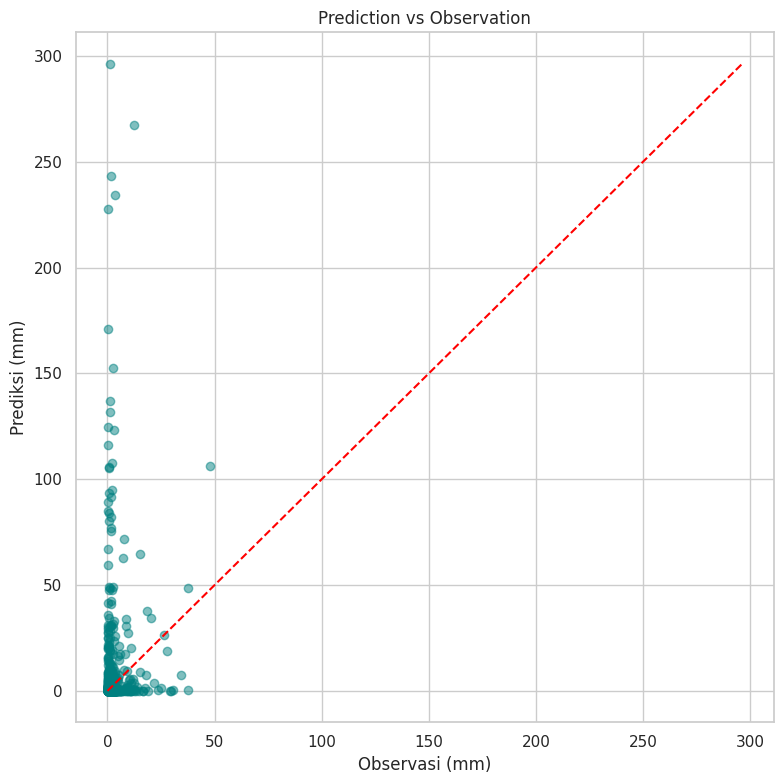

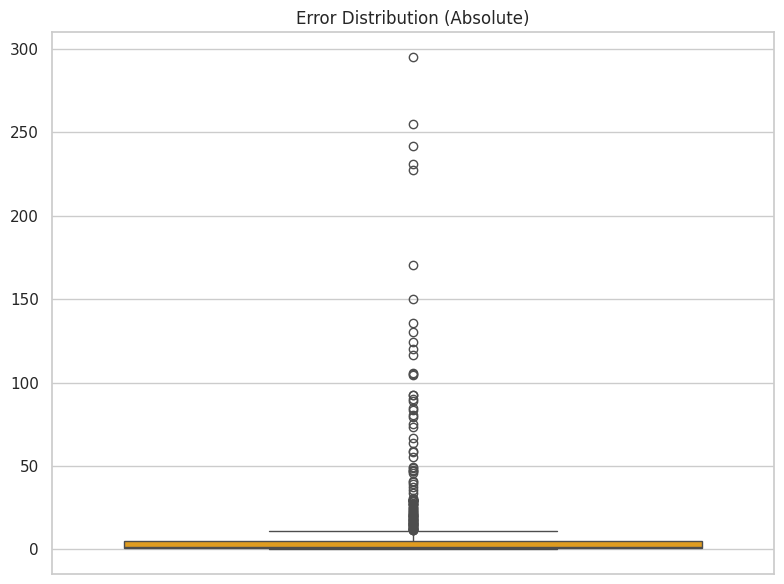

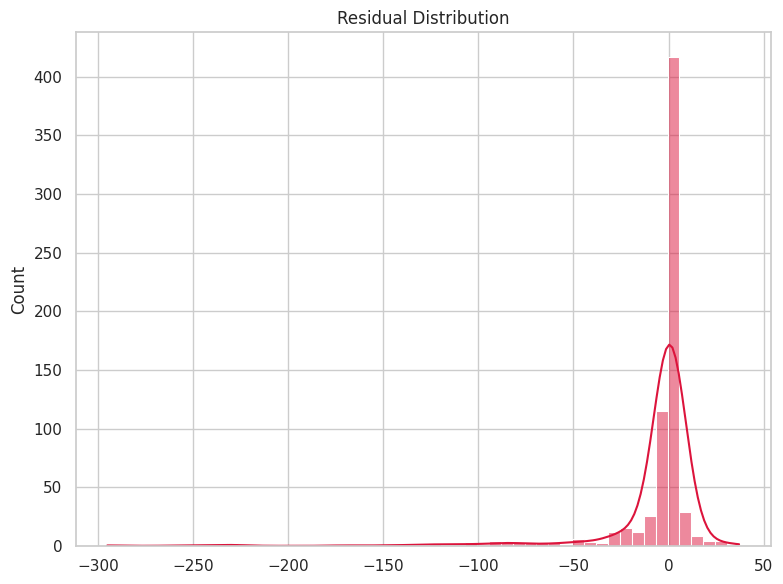

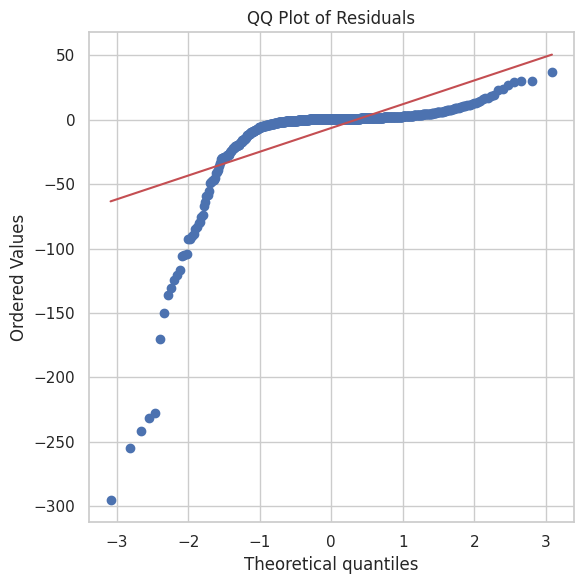

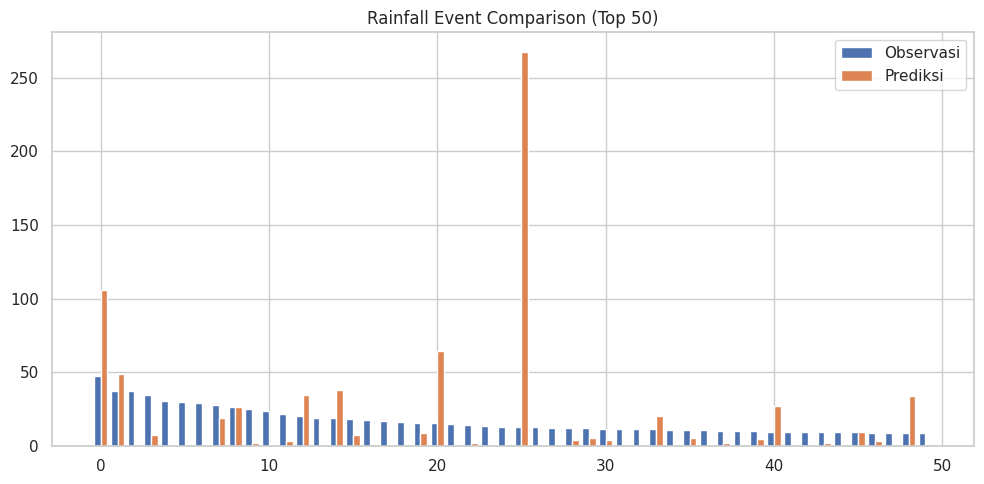

2026-07-01 19:20:15,827 - INFO - Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned...


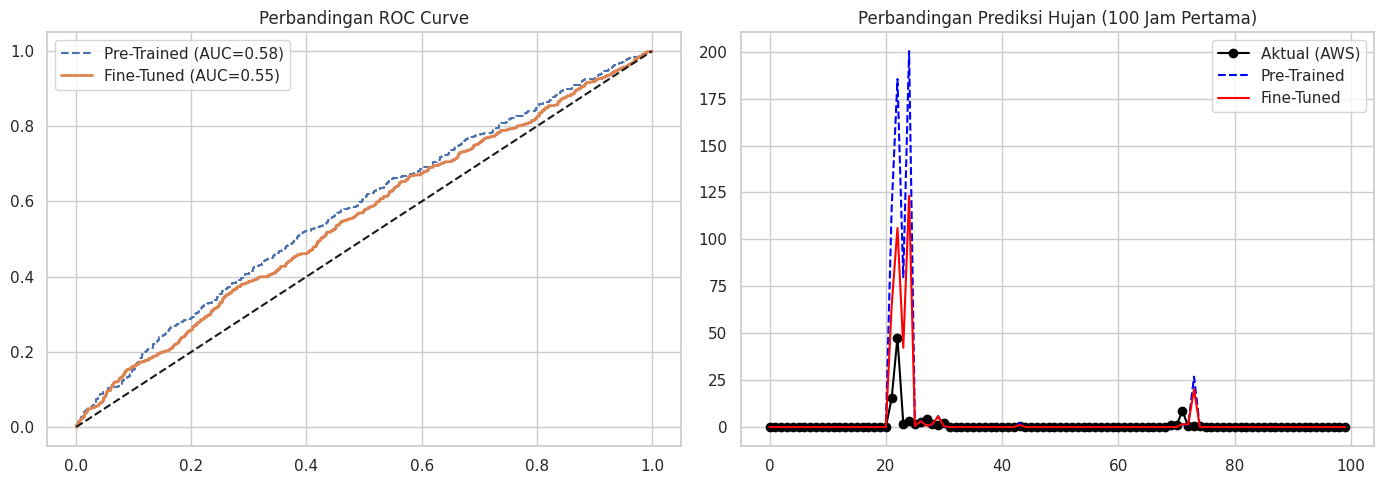

2026-07-01 19:20:16,321 - INFO - Unified Pipeline Selesai!


In [13]:
# Sel 13: Proses Fine-Tuning & Perbandingan Model (LSTM)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import joblib
from sklearn.isotonic import IsotonicRegression

# 1. EVALUASI BEFORE TUNING (Pre-trained Model)
logger.info("Mengevaluasi Model Pre-Trained pada Data Test AWS...")
pre_test_probs = clf_best.predict(X_te_seq, verbose=0).flatten()
pre_test_preds = (pre_test_probs >= 0.5).astype(int)
pre_test_preds_r = np.zeros(len(y_te_o))
rainy_te = y_te_o == 1

if reg_best is not None and np.sum(rainy_te) > 0:
    pre_test_preds_r[rainy_te] = np.clip(np.expm1(reg_best.predict(X_te_seq[rainy_te], verbose=0).flatten()), 0, None)

# 2. PROSES FINE-TUNING
logger.info("Memulai Fine-Tuning Classifier...")
# Compile ulang dengan LR sangat kecil untuk fine-tuning
clf_best.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_clf_ft = clf_best.fit(X_tr_seq, y_tr_o, validation_data=(X_v_seq, y_v_o), epochs=EPOCHS, batch_size=128, callbacks=[es], verbose=0)
clf_best.save(evaluator.dirs['models_clf'] / 'best_lstm_occ_finetuned.h5')

# Calibrator Re-fit
iso_reg = IsotonicRegression(out_of_bounds='clip')
val_probs_uncal = clf_best.predict(X_v_seq, verbose=0).flatten()
iso_reg.fit(val_probs_uncal, y_v_o)
joblib.dump(iso_reg, evaluator.dirs['models_cal'] / 'isotonic_calibrator_finetuned.pkl')

rainy_tr = y_tr_o == 1
rainy_v = y_v_o == 1

if np.sum(rainy_tr) > 10 and reg_best is not None:
    logger.info("Memulai Fine-Tuning Regressor...")
    X_tr_r_val, y_tr_r_val = X_tr_seq[rainy_tr], np.log1p(y_tr_r[rainy_tr])
    X_v_r_val, y_v_r_val = X_v_seq[rainy_v], np.log1p(y_v_r[rainy_v])
    
    reg_best.compile(optimizer=Adam(learning_rate=5e-6), loss='mse')
    es_reg = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    history_reg_ft = reg_best.fit(X_tr_r_val, y_tr_r_val, validation_data=(X_v_r_val, y_v_r_val), epochs=EPOCHS, batch_size=128, callbacks=[es_reg], verbose=0)
    reg_best.save(evaluator.dirs['models_reg'] / 'best_lstm_reg_finetuned.h5')

# 3. EVALUASI AFTER TUNING
test_probs_uncal = clf_best.predict(X_te_seq, verbose=0).flatten()
test_probs_cal = iso_reg.predict(test_probs_uncal)
test_preds_occ = (test_probs_cal >= 0.5).astype(int)

clf_metrics, meteo_metrics = evaluator.evaluate_classification(y_te_o, test_probs_uncal, test_probs_cal, test_preds_occ)
evaluator.plot_confusion_matrix(y_te_o, test_preds_occ)

test_preds_r = np.zeros(len(y_te_o))
if reg_best is not None and np.sum(rainy_te) > 0:
    test_preds_r[rainy_te] = np.clip(np.expm1(reg_best.predict(X_te_seq[rainy_te], verbose=0).flatten()), 0, None)
    reg_metrics = evaluator.evaluate_regression(y_te_r[rainy_te], test_preds_r[rainy_te])

# 4. PLOTTING PERBANDINGAN (Before vs After)
logger.info("Membuat Plot Perbandingan Pre-Trained vs Fine-Tuned...")
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Classification ROC Before vs After
from sklearn.metrics import roc_curve, auc
fpr_pre, tpr_pre, _ = roc_curve(y_te_o, pre_test_probs)
fpr_post, tpr_post, _ = roc_curve(y_te_o, test_probs_uncal)

ax[0].plot(fpr_pre, tpr_pre, label=f'Pre-Trained (AUC={auc(fpr_pre, tpr_pre):.2f})', linestyle='--')
ax[0].plot(fpr_post, tpr_post, label=f'Fine-Tuned (AUC={auc(fpr_post, tpr_post):.2f})', linewidth=2)
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Perbandingan ROC Curve')
ax[0].legend()

# Timeseries Before vs After (100 Jam Pertama)
test_mask_arr = np.where(test_mask)[0]
start_idx = 0
# (Catatan: Index 0 di sini sudah bergeser 24 jam dari awal test set karena sifat sequence LSTM)
end_idx = min(100, len(y_te_r))

ax[1].plot(y_te_r[start_idx:end_idx], label='Aktual (AWS)', color='black', marker='o')
ax[1].plot(pre_test_preds_r[start_idx:end_idx], label='Pre-Trained', color='blue', linestyle='--')
ax[1].plot(test_preds_r[start_idx:end_idx], label='Fine-Tuned', color='red', linestyle='-')
ax[1].set_title('Perbandingan Prediksi Hujan (100 Jam Pertama)')
ax[1].legend()

plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'finetuning_comparison.png')
plt.show()

evaluator.generate_report(len(X_tr_seq), len(X_v_seq), len(X_te_seq), X.columns.tolist(), clf_metrics, meteo_metrics, reg_metrics, "LSTM (Fine-Tuned)")
logger.info("Unified Pipeline Selesai!")


## Analisis SHAP (*Feature Importance* LSTM)

Menghasilkan visualisasi *GradientExplainer* (SHAP) untuk membongkar kotak hitam jaringan saraf tiruan. Grafik ini menunjukkan **variabel mana yang paling kuat pengaruhnya** dalam memicu prediksi hujan lebat.

In [14]:
# Sel Terakhir: Analisis SHAP (Feature Importance)
import shap
import matplotlib.pyplot as plt
import tensorflow as tf
# tf.compat.v1.disable_v2_behavior() # Dibutuhkan untuk DeepExplainer di TF2

logger.info("Membangkitkan plot SHAP untuk Model LSTM...")

try:
    # Gunakan GradientExplainer (lebih stabil di TF2 keras)
    background = X_tr_seq[:100]
    explainer = shap.GradientExplainer(clf_best, background)
    
    # Hitung SHAP values untuk sampel test
    X_shap = X_te_seq[:100]
    shap_values = explainer.shap_values(X_shap)
    
    # Karena input LSTM 3D (samples, timesteps, features), kita FLATTEN (gabung) dimensi waktu untuk summary plot
    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
        
    # Keras TF2/3 kadang mengembalikan tensor 4D (samples, time, features, 1)
    if len(shap_vals.shape) == 4 and shap_vals.shape[-1] == 1:
        shap_vals = shap_vals.squeeze(-1)
    else:
        shap_vals = shap_values
        
    # Keras TF2/3 kadang mengembalikan tensor 4D (samples, time, features, 1)
    if len(shap_vals.shape) == 4 and shap_vals.shape[-1] == 1:
        shap_vals = shap_vals.squeeze(-1)
        
    # Flatten: dari (100, 24, 24) menjadi (2400, 24)
    shap_values_2d = shap_vals.reshape(-1, shap_vals.shape[-1])
    X_shap_2d = X_shap.reshape(-1, X_shap.shape[-1])
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_2d, X_shap_2d, feature_names=X.columns, show=False)
    plt.title('SHAP Feature Importance (LSTM Classifier)')
    plt.tight_layout()
    plt.savefig(evaluator.dirs['plots'] / 'shap_summary_clf.png')
    plt.show()
    logger.info("Plot SHAP berhasil disimpan!")
except Exception as e:
    logger.error(f"SHAP Explainer gagal pada LSTM: {e}")


2026-07-01 19:20:16,410 - INFO - Membangkitkan plot SHAP untuk Model LSTM...
2026-07-01 19:20:17,983 - ERROR - SHAP Explainer gagal pada LSTM: name 'shap_vals' is not defined
